# Time-Domain Simulation

Time-domain simulation (TDS) solves the differential-algebraic equations (DAEs) that govern power system dynamics. This type of analysis is essential for studying transient stability, which determines whether a power system can maintain synchronism following disturbances such as faults, line trips, or generator outages.

ANDES uses the implicit trapezoidal method for numerical integration, which provides a good balance between accuracy and computational efficiency. The method is A-stable, meaning it handles stiff systems well without requiring excessively small time steps.

This tutorial covers running time-domain simulations, adding various types of disturbances, configuring simulation parameters, accessing results, and troubleshooting common issues.

In [1]:
# Reduce logging verbosity for PDF builds
import os
if os.environ.get('SPHINX_BUILD_PDF'):
    import andes
    _orig_config_logger = andes.config_logger
    def _quiet_logger(stream_level=20, *args, **kwargs):
        stream_level = max(stream_level, 30)
        return _orig_config_logger(stream_level, *args, **kwargs)
    andes.config_logger = _quiet_logger

## Setup

In [2]:
%matplotlib inline

import andes
andes.config_logger(stream_level=20)

## Basic Simulation Workflow

A time-domain simulation always begins with a converged power flow solution, which provides the initial steady-state operating point. From this equilibrium, the DAE solver advances time while tracking how system variables evolve in response to any disturbances.

The basic workflow consists of three steps: load the case, run power flow, then run TDS. The simulation end time is controlled by `ss.TDS.config.tf`.

In [3]:
ss = andes.load(andes.get_case('kundur/kundur_full.xlsx'))
ss.PFlow.run()

ss.TDS.config.tf = 10  # Simulate for 10 seconds
ss.TDS.run()

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"


> Loaded config from file "/home/hcui9/.andes/andes.rc"


> Loaded generated Python code in "/home/hcui9/.andes/pycode".


Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...


Input file parsed in 0.0221 seconds.


...

<Toggle 1>: Line.Line_8 status changed to 0 at t=2.0 sec.


Simulation to t=10.00 sec completed in 0.3035 seconds.


Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".


Outputs written in 0.0086 seconds.


True

The Kundur test case includes a pre-defined line trip at t=2 seconds, which triggers electromechanical oscillations between the two areas. The progress bar shows simulation advancement, and the final message confirms successful completion.

### Command Line Alternative

Time-domain simulation can be run from the command line using the `-r tds` flag. The `--tf` option sets the simulation end time.

```bash
andes run kundur_full.xlsx -r tds --tf 20
```

## Adding Disturbances

Disturbances are essential for transient stability analysis because they perturb the system from its equilibrium and allow you to observe the dynamic response. ANDES provides three main disturbance devices:

| Device | Purpose |
|--------|---------|
| `Fault` | Three-phase-to-ground bus fault |
| `Toggle` | Connect or disconnect any device |
| `Alter` | Change parameter values during simulation |

To add disturbances, you must load the case with `setup=False`, add the disturbance devices, then call `setup()` before running. This sequence is necessary because the system structure is finalized during setup.

:::{seealso}
For details on how timed events are implemented internally using `TimerParam` callbacks, see {doc}`../modeling/concepts/system-architecture`.
:::

### Three-Phase Faults

The `Fault` model applies a three-phase-to-ground fault on a bus. This is the most severe type of fault and is commonly used for stability screening. The fault is characterized by its location (bus), application time (`tf`), and clearing time (`tc`).

In [4]:
ss_fault = andes.load(andes.get_case('kundur/kundur_full.xlsx'), setup=False)

# Disable the existing Toggle to isolate the fault effect
ss_fault.Toggle.set('u', 1, 0)

# Add fault on bus 5: apply at t=1.0s, clear at t=1.1s
ss_fault.add('Fault', bus=5, tf=1.0, tc=1.1)

ss_fault.setup()
ss_fault.PFlow.run()
ss_fault.TDS.config.tf = 5
ss_fault.TDS.run()

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"


> Loaded config from file "/home/hcui9/.andes/andes.rc"


> Reloaded generated Python code of module "pycode".


Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...


Input file parsed in 0.0202 seconds.


...

<Fault Fault_2>: Applying fault on Bus (idx=5) at t=1.0 sec.
<Fault Fault_2>: Clearing fault on Bus (idx=5) at t=1.1 sec.


Simulation to t=5.00 sec completed in 0.2252 seconds.


Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".


Outputs written in 0.0045 seconds.


True

The fault parameters control its severity and duration:

| Parameter | Description | Default |
|-----------|-------------|--------|
| `bus` | Bus index for fault location | (required) |
| `tf` | Fault application time [s] | (required) |
| `tc` | Fault clearing time [s] | (required) |
| `rf` | Fault resistance [pu] | 0 |
| `xf` | Fault reactance [pu] | 1e-6 |

For a permanent fault that is never cleared, set `tc` to a time beyond the simulation end.

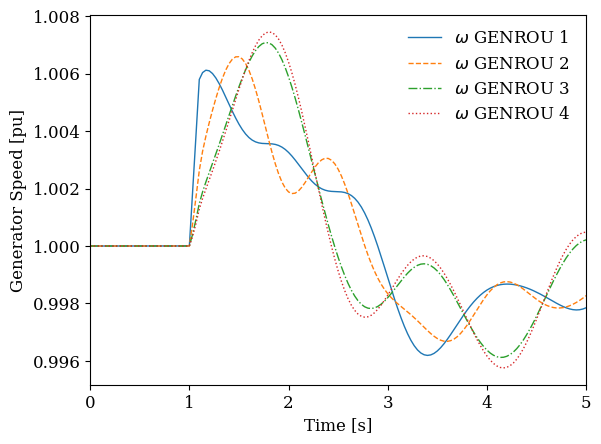

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time [s]', ylabel='Generator Speed [pu]'>)

In [5]:
ss_fault.TDS.plt.plot(ss_fault.GENROU.omega, ylabel='Generator Speed [pu]')

### Line and Device Trips (Toggle)

The `Toggle` model changes the connectivity status of any device at a specified time. This is useful for simulating line trips, generator trips, load shedding, or breaker operations. Unlike faults which modify the network admittance, toggles completely remove or reconnect devices.

The following example demonstrates a line trip followed by reclosure.

In [6]:
ss_toggle = andes.load(andes.get_case('kundur/kundur_full.xlsx'), setup=False)

# Disable existing Toggle
ss_toggle.Toggle.set('u', 1, 0)

# Trip line at t=1.0s, reclose at t=1.5s
ss_toggle.add('Toggle', model='Line', dev='Line_5', t=1.0)
ss_toggle.add('Toggle', model='Line', dev='Line_5', t=1.5)

ss_toggle.setup()
ss_toggle.PFlow.run()
ss_toggle.TDS.config.tf = 5
ss_toggle.TDS.run()

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"


> Loaded config from file "/home/hcui9/.andes/andes.rc"


> Reloaded generated Python code of module "pycode".


Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...


Input file parsed in 0.0203 seconds.


...

Simulation to t=5.00 sec completed in 0.1535 seconds.


Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".


Outputs written in 0.0046 seconds.


<Toggle Toggle_2>: Line.Line_5 status changed to 0 at t=1.0 sec.
<Toggle Toggle_3>: Line.Line_5 status changed to 1 at t=1.5 sec.


True

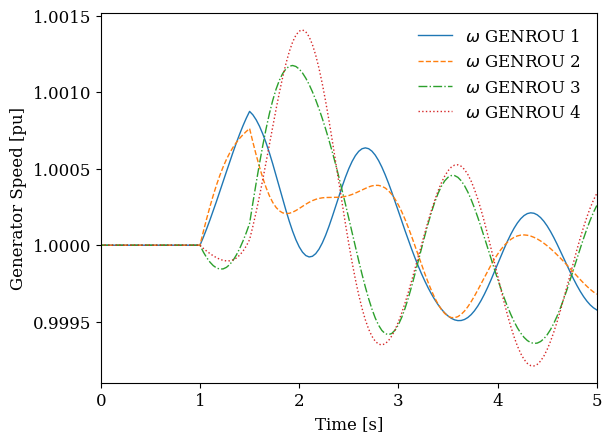

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time [s]', ylabel='Generator Speed [pu]'>)

In [7]:
ss_toggle.TDS.plt.plot(ss_toggle.GENROU.omega, ylabel='Generator Speed [pu]')

Toggle can operate on any model type. Common applications include:

- **Generator trip**: `ss.add('Toggle', model='GENROU', dev='GENROU_2', t=1.0)`
- **Load shedding**: `ss.add('Toggle', model='PQ', dev='PQ_1', t=2.0)`
- **Transformer trip**: `ss.add('Toggle', model='Line', dev='Line_10', t=0.5)`

### Parameter Changes (Alter)

The `Alter` model changes parameter or service values at specified times during simulation. This is useful for studying the effect of setpoint changes, such as adjusting governor references or exciter voltage setpoints. The alteration is specified by the source field (`src`), the method (`=`, `+`, `-`, `*`, `/`), and the amount to apply.

In [8]:
ss_alter = andes.load(andes.get_case('kundur/kundur_full.xlsx'), setup=False)

# Disable existing Toggle
ss_alter.Toggle.set('u', 1, 0)

# Step change in governor setpoint at t=1.0s
ss_alter.add('Alter', model='TGOV1', dev=1, src='pref0',
             t=1.0, method='=', amount=0.8)

ss_alter.setup()
ss_alter.PFlow.run()
ss_alter.TDS.config.tf = 10
ss_alter.TDS.run()

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"


> Loaded config from file "/home/hcui9/.andes/andes.rc"


> Reloaded generated Python code of module "pycode".


Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...


Input file parsed in 0.0204 seconds.


...

<Alter Alter_2>: set TGOV1.1.pref0.v=0.8 at t=1. Previous value was 7.26803.


Simulation to t=10.00 sec completed in 0.4519 seconds.


Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".


Outputs written in 0.0088 seconds.


True

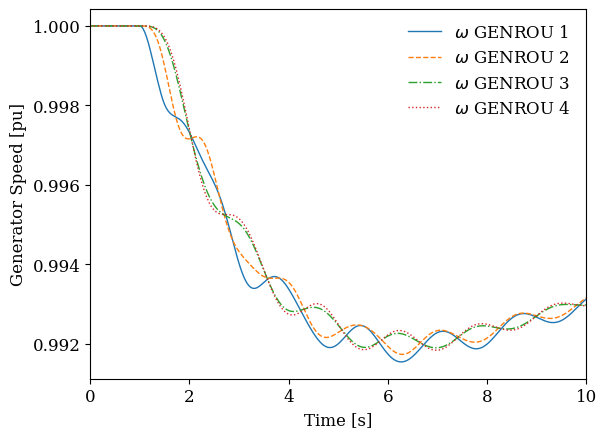

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time [s]', ylabel='Generator Speed [pu]'>)

In [9]:
ss_alter.TDS.plt.plot(ss_alter.GENROU.omega, ylabel='Generator Speed [pu]')

### Altering Dynamic vs. Static Models

During TDS initialization, dynamic models disable their linked static models and take over power injection. For example, `GENROU` disables its linked `PV` generator, and `FLoad` disables its linked `PQ` load.

This means that altering a parameter on the disabled static model has no effect during simulation. A common mistake is trying to change generator output by altering `PV.p0`, which has no effect because `PV` has been disabled by `GENROU`. The correct approach is to alter the governor setpoint:

```python
# Wrong: PV is disabled by GENROU, has no effect
ss.add('Alter', model='PV', dev=2, src='p0', t=1.0, method='+', amount=-0.5)

# Correct: alter the governor reference power
ss.add('Alter', model='TGOV1', dev=1, src='pref0', t=1.0, method='+', amount=-0.5)
```

:::{tip}
For interactive (non-timed) setpoint changes between simulation stages, the group-level setpoint API is recommended. It resolves the controller chain automatically so that the user does not need to know the specific governor or exciter model:

```python
ss.SynGen.set_pref(ss, gen_idx, new_value)   # writes to governor pref0
ss.SynGen.set_vref(ss, gen_idx, new_value)    # writes to exciter vref0
ss.SynGen.set_paux(ss, gen_idx, new_value)    # writes to governor paux0
```

See {doc}`10-dynamic-control` for a complete example.
:::

The table below lists common dynamic-static pairs and the correct target for alterations:

| Dynamic Model | Disables | Wrong Target | Correct Target |
|---------------|----------|--------------|----------------|
| `GENROU`/`GENCLS` | `PV`/`Slack` | `PV.p0` | `TGOV1.pref0` or `paux0` |
| `FLoad` | `PQ` | `PQ.Ppf` | `FLoad.pv0` |
| `ZIP` | `PQ` | `PQ.Ppf` | `ZIP.Sp` |

:::{note}
When no dynamic model is attached, the static model remains active. For example, altering `PQ.Ppf` works for load shedding when no `FLoad` or `ZIP` is present. See {doc}`11-frequency-response` for an example.
:::

## Configuration Options

The TDS routine provides several configuration options that control simulation behavior. These can be accessed and modified through `ss.TDS.config`.

In [10]:
ss.TDS.config

OrderedDict([('linsolve', 0),
             ('method', 'trapezoid'),
             ('tol', 0.0001),
             ('t0', 0.0),
             ('tf', 20.0),
             ('fixt', 1),
             ('shrinkt', 1),
             ('honest', 0),
             ('tstep', 0.03333333333333333),
             ('max_iter', 15),
             ('refresh_event', 0),
             ('test_init', 1),
             ('check_conn', 1),
             ('criteria', 1),
             ('ddelta_limit', 180),
             ('g_scale', 1),
             ('reset_tiny', 1),
             ('qrt', 0),
             ('kqrt', 1.0),
             ('store_z', 0),
             ('store_f', 0),
             ('store_h', 0),
             ('store_i', 0),
             ('limit_store', 0),
             ('max_store', 900),
             ('save_every', 1),
             ('save_mode', 'auto'),
             ('no_tqdm', 0),
             ('chatter_iter', 4),
             ('linesearch', 1),
             ('dtmax', 0),
             ('dtmin_adapt', 0),
       

The most commonly adjusted options are:

| Option | Default | Description |
|--------|---------|-------------|
| `tf` | 20 | Simulation end time [seconds] |
| `tstep` | 1/30 | Integration time step [seconds] |
| `max_iter` | 15 | Maximum Newton iterations per step |
| `tol` | 1e-6 | Convergence tolerance |
| `fixt` | 1 | Use fixed (1) or variable (0) step size |

For simulations with fast dynamics or discontinuities, you may need to reduce the time step to maintain accuracy and stability.

## Accessing Results

After simulation, the `get_timeseries()` method on `ss.TDS` is the easiest way to extract results as a pandas DataFrame. Pass any variable object and it returns a DataFrame with time as the index and device indices as columns — no need to know whether the variable is a state or algebraic quantity.

### Using `get_timeseries()`

In [11]:
# Generator speeds — returns a DataFrame automatically
omega_df = ss.TDS.get_timeseries(ss.GENROU.omega)
print(omega_df.head())

            1    2    3    4
0.000000  1.0  1.0  1.0  1.0
0.033333  1.0  1.0  1.0  1.0
0.066667  1.0  1.0  1.0  1.0
0.100000  1.0  1.0  1.0  1.0
0.133333  1.0  1.0  1.0  1.0


In [12]:
# Bus voltages — works the same way regardless of variable type
voltage_df = ss.TDS.get_timeseries(ss.Bus.v)
print(f"Voltage DataFrame shape: {voltage_df.shape}")
print(f"Columns (bus indices): {list(voltage_df.columns)}")

Voltage DataFrame shape: (303, 10)
Columns (bus indices): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


The returned DataFrame can be used directly for analysis or export:

```python
# Export to CSV
omega_df.to_csv('omega_results.csv')

# Quick statistics
print(omega_df.max())

# Slice a single device
omega_gen1 = omega_df[1]  # Generator with idx=1
```

### Advanced: Direct DAE Access

Under the hood, time series data is stored in `ss.dae.ts`. State variables (like generator speed) are in `ss.dae.ts.x` and algebraic variables (like bus voltage) are in `ss.dae.ts.y`. Each variable has an `.a` attribute containing its address(es) into these arrays.

```python
# State variable: use dae.ts.x
omega_addr = ss.GENROU.omega.a        # array([4, 5, 6, 7])
omega_ts = ss.dae.ts.x[:, omega_addr] # shape: (n_steps, 4)

# Algebraic variable: use dae.ts.y
v_addr = ss.Bus.v.a
voltage_ts = ss.dae.ts.y[:, v_addr]   # shape: (n_steps, 10)

# Time vector
t = ss.dae.ts.t
```

This direct access is useful when you need maximum performance or are working with custom numerical analysis.

## Plotting Results

ANDES provides a built-in plotter accessible through `ss.TDS.plt` that simplifies visualization of simulation results. The `plot()` method accepts variable objects and automatically handles address lookup and data extraction.

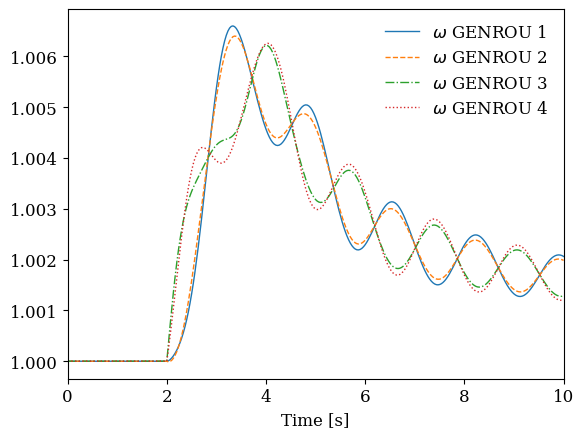

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [13]:
# Plot all generator speeds
ss.TDS.plt.plot(ss.GENROU.omega)

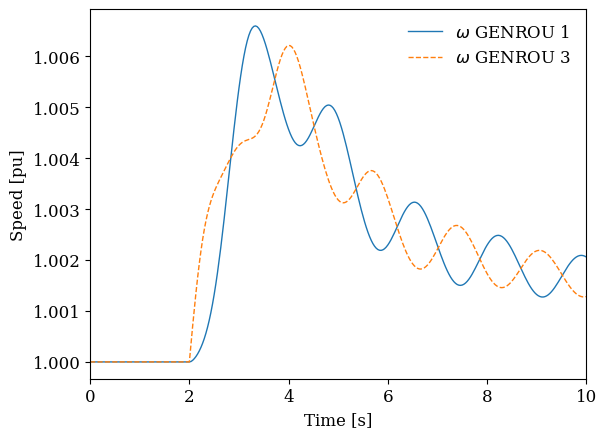

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time [s]', ylabel='Speed [pu]'>)

In [14]:
# Plot specific generators using address indices
ss.TDS.plt.plot(ss.GENROU.omega, a=[0, 2], ylabel='Speed [pu]')

### Exporting Results

Results can be exported to CSV format for further analysis in other tools.

In [15]:
ss.TDS.plt.export_csv('kundur_results.csv')

CSV data saved to "kundur_results.csv".


'kundur_results.csv'

## Multi-Stage Simulation

For complex scenarios, the simulation can be run in multiple stages with setpoint changes between stages. After completing one stage, the end time is updated and `run()` is called again. ANDES continues from where it left off, preserving all state variables.

The group-level setpoint API is used to apply changes between stages. See {doc}`10-dynamic-control` for a detailed tutorial.

In [16]:
ss_multi = andes.load(andes.get_case('kundur/kundur_full.xlsx'), setup=False)
ss_multi.Toggle.set('u', 1, 0)  # Disable existing toggle
ss_multi.setup()
ss_multi.PFlow.run()

# Stage 1: Run to t=2s
ss_multi.TDS.config.tf = 2.0
ss_multi.TDS.run()

# Apply setpoint change between stages using the group-level API
gen_idx = ss_multi.GENROU.idx.v[0]
ss_multi.SynGen.set_paux(ss_multi, gen_idx, 0.05)

# Stage 2: Continue to t=10s
ss_multi.TDS.config.tf = 10.0
ss_multi.TDS.run()

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"


> Loaded config from file "/home/hcui9/.andes/andes.rc"


> Reloaded generated Python code of module "pycode".


Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...


Input file parsed in 0.0202 seconds.


...

Outputs written in 0.0021 seconds.


Simulation to t=10.00 sec completed in 0.2882 seconds.


Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".


Outputs written in 0.0083 seconds.


True

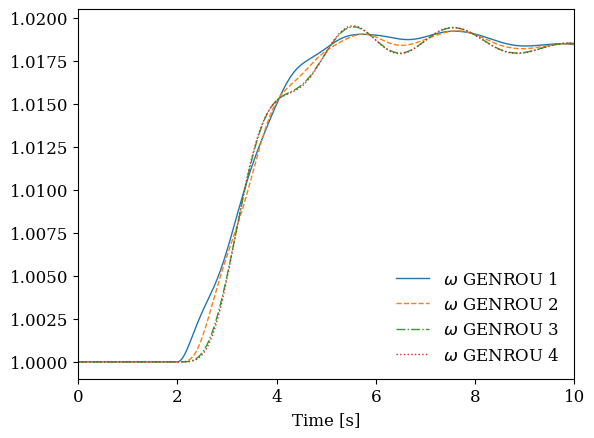

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [17]:
# Plot shows both stages seamlessly
ss_multi.TDS.plt.plot(ss_multi.GENROU.omega)

## Output Files

TDS automatically generates output files containing simulation results:

| File | Description |
|------|-------------|
| `*_out.lst` | Variable listing with indices and names |
| `*_out.npz` | Compressed NumPy archive with time series data |

These files can be loaded later for post-processing without re-running the simulation.

In [18]:
import numpy as np

# Load saved results
data = np.load(ss.files.npz)
print("Available arrays:", list(data.keys()))

Available arrays: ['data']


## Troubleshooting

### Simulation Fails to Converge

If the simulation fails during integration, the Newton iteration at a particular time step did not converge within the allowed iterations. This usually indicates:

1. **Step size too large**: Reduce `tstep` to capture faster dynamics
2. **Severe disturbance**: The system may be transiently unstable
3. **Model limitations**: Some operating points may exceed model validity ranges

In [19]:
# Typical remedies for convergence issues
ss.TDS.config.tstep = 0.001  # Smaller step size
ss.TDS.config.max_iter = 30  # More iterations allowed

### Checking Initialization

Before running a full simulation, you can initialize TDS without running to check for any initialization errors. This helps identify problems with initial conditions before committing to a long simulation.

In [20]:
ss_check = andes.load(andes.get_case('kundur/kundur_full.xlsx'))
ss_check.PFlow.run()
ss_check.TDS.init()  # Initialize only, don't run

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"


> Loaded config from file "/home/hcui9/.andes/andes.rc"


> Reloaded generated Python code of module "pycode".


Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...


Input file parsed in 0.0249 seconds.


...

Report saved to "kundur_full_out.txt" in 0.0005 seconds.


DAE compaction: removed 5 algebraic variable slots (m: 149 -> 144)


Initialization for dynamics completed in 0.0085 seconds.


Initialization was successful.


array([ 1.41994833,  1.12395571,  0.93892059,  1.21137566,  1.        ,
        1.        ,  1.        ,  1.        ,  0.86626507,  0.94860464,
        0.95125532,  0.868703  ,  0.5080822 ,  0.45912205,  0.45770681,
        0.50085419,  0.70142377,  0.77725184,  0.77932427,  0.71147986,
        0.72456939,  0.65474796,  0.65272971,  0.71426163,  7.26802908,
        7.        ,  7.        ,  7.        ,  7.26802908,  7.        ,
        7.        ,  7.        ,  1.89652317,  2.0195597 ,  2.02582439,
        1.85134764,  1.        ,  1.        ,  1.        ,  1.        ,
        0.09482616,  0.10097799,  0.10129122,  0.09256738,  1.89652317,
        2.0195597 ,  2.02582439,  1.85134764,  1.89652317,  2.0195597 ,
        2.02582439,  1.85134764,  0.57025492,  0.37796171,  0.1957715 ,
        0.3777206 ,  0.4825648 ,  0.293535  ,  0.1425481 , -0.03712551,
        0.1113441 ,  0.29331307,  1.        ,  1.        ,  1.        ,
        1.        ,  0.98337472,  0.96908586,  0.95621812,  0.95

### Flat Run Test

A "flat run" without any disturbances verifies that the system stays at equilibrium. If variables drift during a flat run, there may be inconsistencies in the initial conditions or model parameters.

```bash
andes run case.xlsx -r tds --flat
```

## Cleanup

In [21]:
!andes misc -C
!rm -f kundur_results.csv

"/home/hcui9/repos/andes/docs/source/tutorials/kundur_p_13.91_out.lst" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_p_13.91_out.npz" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_p_13.91_out.txt" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_full_out.lst" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_full_out.npz" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_p_12.75_out.txt" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/ieee14_out.txt" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_p_11.59_out.lst" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_p_11.59_out.txt" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_full_out.txt" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_p_12.75_out.lst" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/ieee14_out.lst" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_p_11.59_out

## Next Steps

- {doc}`05-data-and-formats` - Loading different file formats and modifying parameters
- {doc}`06-plotting-results` - Advanced plotting and result visualization
- {doc}`07-eigenvalue-analysis` - Small-signal stability analysis